In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import re
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

In [2]:
rows = []

with open("exp_file_paper_130.log") as f:
    for line in f:
        match = re.match(r"([\d.]+)s\s+\[Trial success\]\s+(\S+)", line)
        if match:
            rows.append({
                "time_s": float(match.group(1)),
                "experiment": match.group(2)
            })

df = pd.DataFrame(rows)
print(df)


     time_s experiment
0      11.4    1_11111
1      11.5    1_11111
2      12.1    1_11111
3      13.6    1_11111
4      11.6    1_11111
..      ...        ...
535    12.4   18_32212
536    13.9   18_32212
537    13.5   18_32212
538    12.6   18_32212
539    12.4   18_32212

[540 rows x 2 columns]


In [5]:
summary = (
    df.groupby("experiment")["time_s"]
      .agg(mean="mean", std="std")
      .sort_index(key=lambda idx: idx.str.split("_").str[0].astype(int))
)

summary

,mean,std
experiment,,
1_11111,11.963333,0.612222
2_11222,13.353333,0.448548
3_11121,12.360000,0.382009
4_12111,12.753333,0.528324
5_12222,12.323333,0.405721
6_12211,12.373333,0.541348
7_21121,12.280000,0.410551
8_21222,13.336667,0.400416
9_21112,12.650000,0.486189


In [6]:
summary = summary.reset_index()

# split id and code
summary["code"] = summary["experiment"].str.split("_").str[1]

# mappings
connective_map = {"1": "OR", "2": "XOR", "3": "AND"}
negation_map = {"1": "No", "2": "Yes"}
truth_map = {"1": "T", "2": "F"}

# decode columns
summary["Conj."] = summary["code"].str[0].map(connective_map)
summary["Neg."] = summary["code"].str[1].map(negation_map)
p1 = summary["code"].str[2].map(truth_map)
p2 = summary["code"].str[3].map(truth_map)

summary["Prop."] = p1 + p2
summary["Sent."] = summary["code"].str[4].map(truth_map)

In [7]:
summary["Prop."] = summary["Prop."].replace({
    "TF": "TF/FT",
    "FT": "TF/FT"
})

In [8]:
summary = summary[[
    "Conj.",
    "Neg.",
    "Prop.",
    "Sent.",
    "mean",
    "std"
]]

summary

,Conj.,Neg.,Prop.,Sent.,mean,std
0,OR,No,TT,T,11.963333,0.612222
1,OR,No,FF,F,13.353333,0.448548
2,OR,No,TF/FT,T,12.360000,0.382009
3,OR,Yes,TT,T,12.753333,0.528324
4,OR,Yes,FF,F,12.323333,0.405721
5,OR,Yes,TF/FT,T,12.373333,0.541348
6,XOR,No,TF/FT,T,12.280000,0.410551
7,XOR,No,FF,F,13.336667,0.400416
8,XOR,No,TT,F,12.650000,0.486189
9,XOR,Yes,TF/FT,T,12.230000,0.427624


In [9]:
conj_order = ["OR", "XOR", "AND"]
neg_order = ["No", "Yes"]
prop_order = ["TT", "TF/FT", "FF"]

summary["Conj."] = pd.Categorical(
    summary["Conj."],
    categories=conj_order,
    ordered=True
)

summary["Neg."] = pd.Categorical(
    summary["Neg."],
    categories=neg_order,
    ordered=True
)

summary["Prop."] = pd.Categorical(
    summary["Prop."],
    categories=prop_order,
    ordered=True
)

summary = summary.sort_values(
    by=["Conj.", "Neg.", "Prop."]
).reset_index(drop=True)

summary

,Conj.,Neg.,Prop.,Sent.,mean,std
0,OR,No,TT,T,11.963333,0.612222
1,OR,No,TF/FT,T,12.360000,0.382009
2,OR,No,FF,F,13.353333,0.448548
3,OR,Yes,TT,T,12.753333,0.528324
4,OR,Yes,TF/FT,T,12.373333,0.541348
5,OR,Yes,FF,F,12.323333,0.405721
6,XOR,No,TT,F,12.650000,0.486189
7,XOR,No,TF/FT,T,12.280000,0.410551
8,XOR,No,FF,F,13.336667,0.400416
9,XOR,Yes,TT,F,13.266667,0.500574


In [10]:
#Add number of delays as a column
numd = [0, 1, 3, 2, 1, 1, 1, 1, 3, 3, 1, 1, 0, 2, 3, 2, 2, 1]

summary.insert(4, "Num. D.", numd)

summary

,Conj.,Neg.,Prop.,Sent.,Num. D.,mean,std
0,OR,No,TT,T,0,11.963333,0.612222
1,OR,No,TF/FT,T,1,12.360000,0.382009
2,OR,No,FF,F,3,13.353333,0.448548
3,OR,Yes,TT,T,2,12.753333,0.528324
4,OR,Yes,TF/FT,T,1,12.373333,0.541348
5,OR,Yes,FF,F,1,12.323333,0.405721
6,XOR,No,TT,F,1,12.650000,0.486189
7,XOR,No,TF/FT,T,1,12.280000,0.410551
8,XOR,No,FF,F,3,13.336667,0.400416
9,XOR,Yes,TT,F,3,13.266667,0.500574


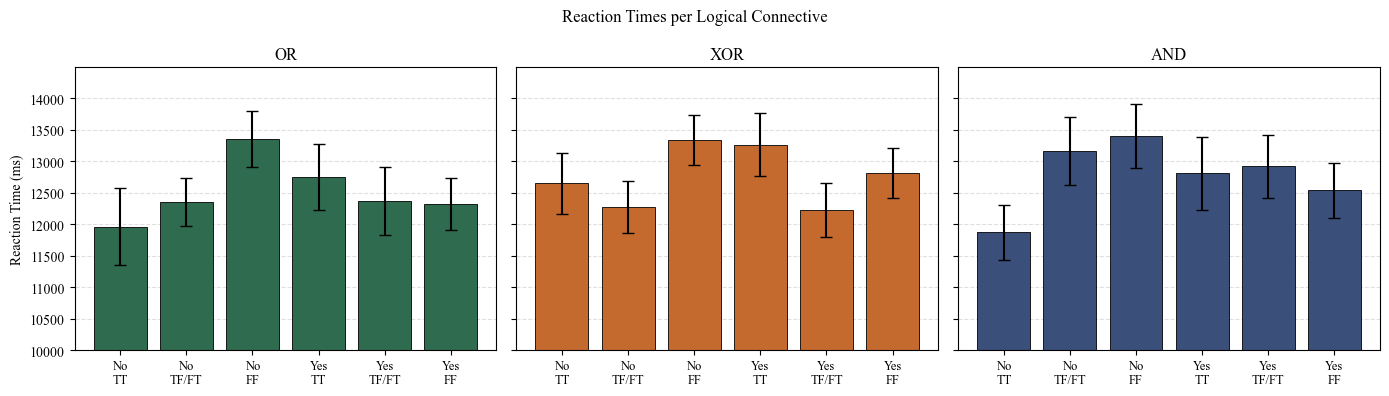

In [11]:
#Figure with RTs per logical connective with SDs
plt.rcParams['font.family'] = 'Times New Roman'

color_map = {
    'OR':  '#2F6B4F',
    'XOR': '#C46A2F',
    'AND': '#3A4F7A'
}

# enforce plotting order
prop_order = ["TT", "TF/FT", "FF"]
neg_order = ["No", "Yes"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, lc in zip(axes, ["OR", "XOR", "AND"]):
    data = summary[summary["Conj."] == lc].copy()

    # enforce internal order
    data["Prop."] = pd.Categorical(data["Prop."], prop_order, ordered=True)
    data["Neg."]  = pd.Categorical(data["Neg."],  neg_order,  ordered=True)
    data = data.sort_values(["Neg.", "Prop."])

    means = data["mean"].values * 1000  # ms
    stds  = data["std"].values  * 1000  # ms

    x = np.arange(len(means))

    ax.bar(
        x,
        means,
        yerr=stds,
        capsize=4,
        color=color_map[lc],
        edgecolor="black",
        linewidth=0.6
    )

    # x-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{n}\n{p}" for n, p in zip(data["Neg."], data["Prop."])],
        fontsize=9
    )

    ax.set_title(lc)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    ax.yaxis.set_major_locator(MultipleLocator(500))
    ax.set_ylim(bottom=10000)

axes[0].set_ylabel("Reaction Time (ms)")

plt.suptitle("Reaction Times per Logical Connective", fontsize=12)
plt.tight_layout()
plt.show()

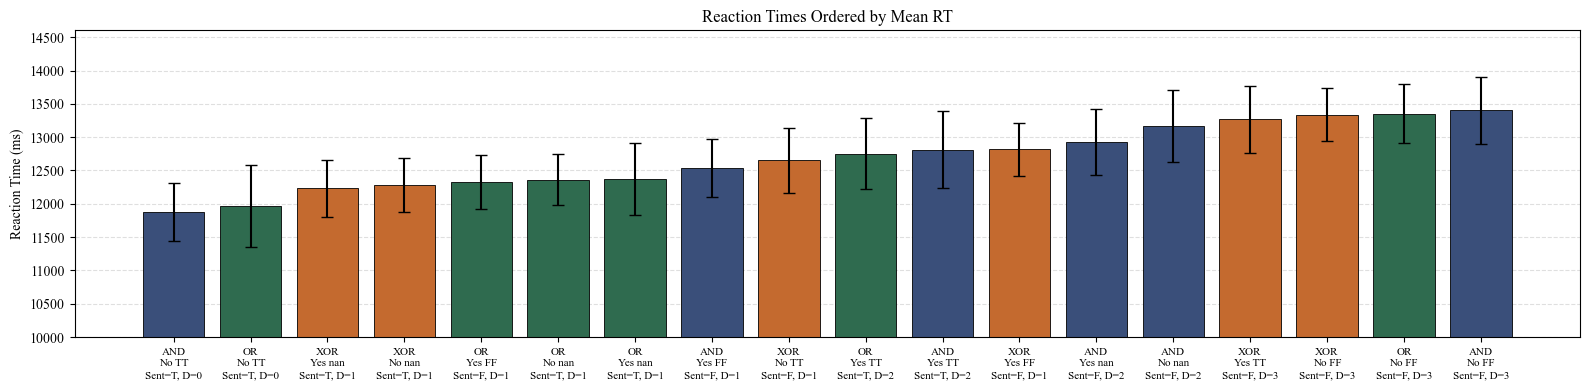

In [12]:
plt.rcParams['font.family'] = 'Times New Roman'

color_map = {
    'OR':  '#2F6B4F',
    'XOR': '#C46A2F',
    'AND': '#3A4F7A'
}

# enforce categorical order (for labels only)
summary["Conj."] = pd.Categorical(summary["Conj."], ["OR", "XOR", "AND"], ordered=True)
summary["Neg."]  = pd.Categorical(summary["Neg."],  ["No", "Yes"], ordered=True)
summary["Prop."] = pd.Categorical(summary["Prop."], ["TT", "TF", "FF"], ordered=True)

# SORT BY MEAN RT
plot_data = summary.sort_values("mean").reset_index(drop=True)

x = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(16, 4))

ax.bar(
    x,
    plot_data["mean"] * 1000,
    yerr=plot_data["std"] * 1000,
    capsize=4,
    color=plot_data["Conj."].map(color_map),
    edgecolor="black",
    linewidth=0.6
)

# x-axis labels: everything goes under the bar
ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"{c}\n{n} {p}\nSent={s}, D={d}"
        for c, n, p, s, d in zip(
            plot_data["Conj."],
            plot_data["Neg."],
            plot_data["Prop."],
            plot_data["Sent."],
            plot_data["Num. D."]
        )
    ],
    fontsize=8
)

ax.set_ylabel("Reaction Time (ms)")
ax.set_title("Reaction Times Ordered by Mean RT")

ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(MultipleLocator(500))
ax.set_ylim(bottom=10000)

plt.tight_layout()
plt.show()

In [71]:
summary.head()

,Conj.,Neg.,Prop.,Sent.,Num. D.,mean,std
0,OR,No,TT,T,0,11.963333,0.612222
1,OR,No,NaN,T,1,12.360000,0.382009
2,OR,No,FF,F,3,13.353333,0.448548
3,OR,Yes,TT,T,2,12.753333,0.528324
4,OR,Yes,NaN,T,1,12.373333,0.541348


In [13]:
summary["mean"] = summary["mean"].values * 1000  # ms
summary["std"] = summary["std"].values * 1000  # ms
summary

,Conj.,Neg.,Prop.,Sent.,Num. D.,mean,std
0,OR,No,TT,T,0,11963.333333,612.222257
1,OR,No,NaN,T,1,12360.000000,382.009207
2,OR,No,FF,F,3,13353.333333,448.548105
3,OR,Yes,TT,T,2,12753.333333,528.324178
4,OR,Yes,NaN,T,1,12373.333333,541.347828
5,OR,Yes,FF,F,1,12323.333333,405.720588
6,XOR,No,TT,F,1,12650.000000,486.188554
7,XOR,No,NaN,T,1,12280.000000,410.550514
8,XOR,No,FF,F,3,13336.666667,400.416450
9,XOR,Yes,TT,F,3,13266.666667,500.574383


In [73]:
summary["ID"] = range(1, len(summary) + 1)
summary.head()

,Conj.,Neg.,Prop.,Sent.,Num. D.,mean,std,ID
0,OR,No,TT,T,0,11963.333333,612.222257,1
1,OR,No,NaN,T,1,12360.000000,382.009207,2
2,OR,No,FF,F,3,13353.333333,448.548105,3
3,OR,Yes,TT,T,2,12753.333333,528.324178,4
4,OR,Yes,NaN,T,1,12373.333333,541.347828,5


In [74]:
summary = summary.sort_values("mean").reset_index(drop=True)
summary.head()

,Conj.,Neg.,Prop.,Sent.,Num. D.,mean,std,ID
0,AND,No,TT,T,0,11873.333333,433.854682,13
1,OR,No,TT,T,0,11963.333333,612.222257,1
2,XOR,Yes,NaN,T,1,12230.000000,427.623747,11
3,XOR,No,NaN,T,1,12280.000000,410.550514,8
4,OR,Yes,FF,F,1,12323.333333,405.720588,6


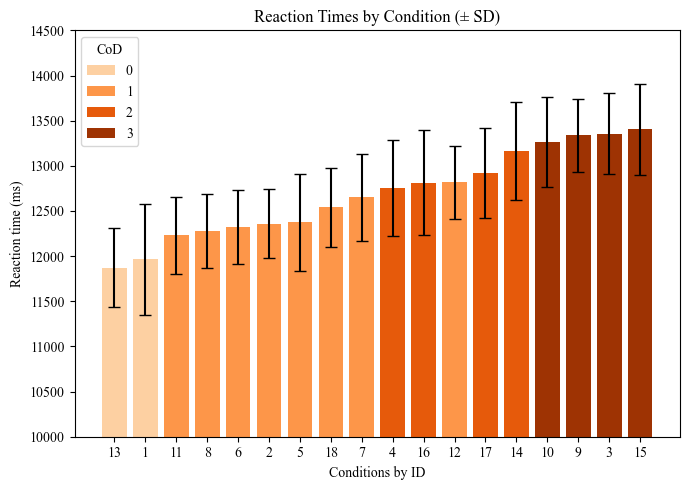

In [82]:
# --- truncate colormap ---
def truncate_colormap(cmap, minval=0.25, maxval=0.9, n=256):
    return LinearSegmentedColormap.from_list(
        "trunc_cmap", cmap(np.linspace(minval, maxval, n))
    )

cmap = truncate_colormap(cm.Oranges, 0.25, 0.9)

# --- define categorical levels and colors (ordered) ---
levels = sorted(summary["Num. D."].unique())
level_colors = {
    lvl: cmap(i / (len(levels) - 1)) for i, lvl in enumerate(levels)
}

# map colors to bars
colors = summary["Num. D."].map(level_colors)

# --- x positions ---
x = np.arange(len(summary))

# --- plot ---
plt.figure(figsize=(7, 5))

plt.bar(
    x,
    summary["mean"],
    yerr=summary["std"],
    capsize=4,
    color=colors
)

plt.ylim(10000, 14500)
plt.yticks(range(10000, 14501, 500))

plt.xlabel("Conditions by ID")
plt.ylabel("Reaction time (ms)")
plt.title("Reaction Times by Condition (± SD)")
plt.xticks(x, summary["ID"])

# --- categorical legend ---
legend_handles = [
    Patch(facecolor=level_colors[lvl], label=f"{lvl}")
    for lvl in levels
]

plt.legend(
    handles=legend_handles,
    title="CoD"
)

plt.tight_layout()
plt.show()
